# This notebook covers handling of missing values by simply dropping them. <br>
## It is also called Complete Case Analysis(CCA).
It also covers complete analysis of conditions and scenarios where CCA can be effective and may perform poor.


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [74]:
df = pd.read_csv("data_science_job.csv")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [75]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [76]:
df.shape

(19158, 13)

In [77]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'training_hours', 'target'],
      dtype='str')

In [78]:
# extracting column names whose null values are bw 0 and 5 % of the column data.
cols = [col for col in df.columns if (df[col].isnull().mean() < 0.05) and (df[col].isnull().mean() > 0.0)] 
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [79]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
6038,0.893,Part time course,Graduate,6.0,5.0
972,0.804,Full time course,Graduate,4.0,33.0
15677,0.926,Full time course,Graduate,7.0,9.0
4062,0.897,no_enrollment,Graduate,20.0,156.0
6433,0.910,no_enrollment,Graduate,20.0,66.0


In [80]:
df[cols].isnull().mean()*100

city_development_index    2.500261
enrolled_university       2.014824
education_level           2.401086
experience                0.339284
training_hours            3.998330
dtype: float64

In [81]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [82]:
# percentage of data left after dropping the missing values in columns where the missing value is < 5%
(len(df[cols].dropna()))/len(df)

0.8968577095730244

In [83]:
reduced_df = df[cols].dropna()
df.shape,reduced_df.shape

((19158, 13), (17182, 5))

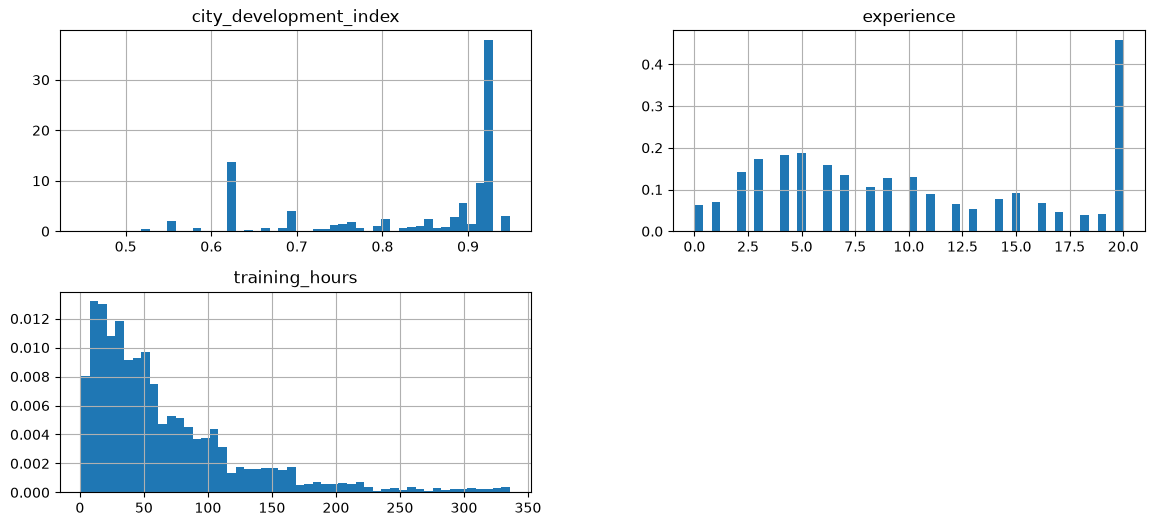

In [88]:
reduced_df.hist(bins=50,density=True,figsize=(14,6))
plt.show()

<Axes: >

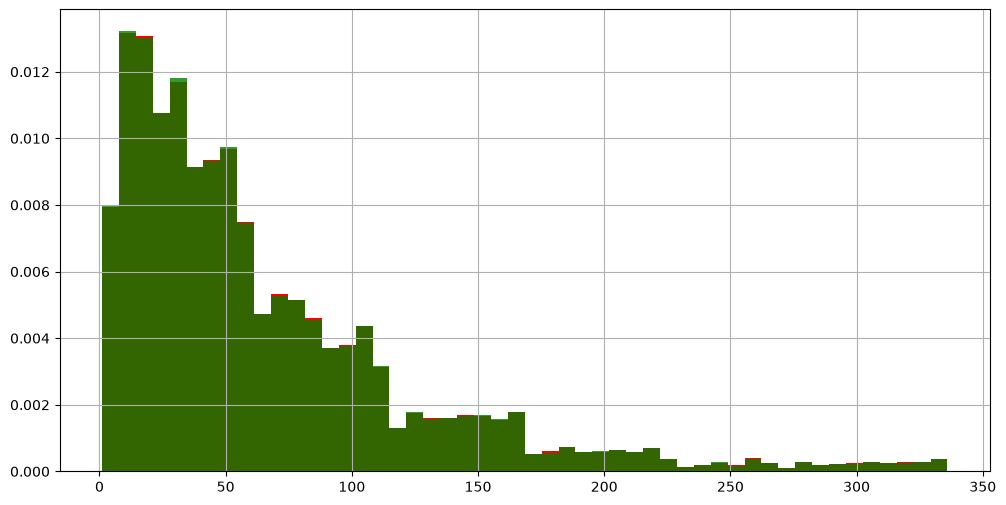

In [114]:
fig = plt.figure()
ax = fig.add_subplot(111)

# distribution of the orginal data 
df['training_hours'].hist(bins=50,ax=ax,density=True,figsize=(12,6),color='red')


# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
reduced_df['training_hours'].hist(bins=50,ax=ax,density=True,color='green',alpha = 0.8)

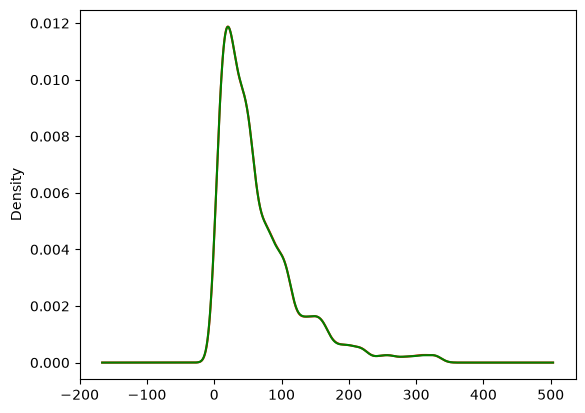

In [122]:
fig = plt.figure()
ax = fig.add_subplot(111)
# original data 
df['training_hours'].plot.density(color='red')

# after cca
reduced_df['training_hours'].plot.density(color='green')

plt.show()

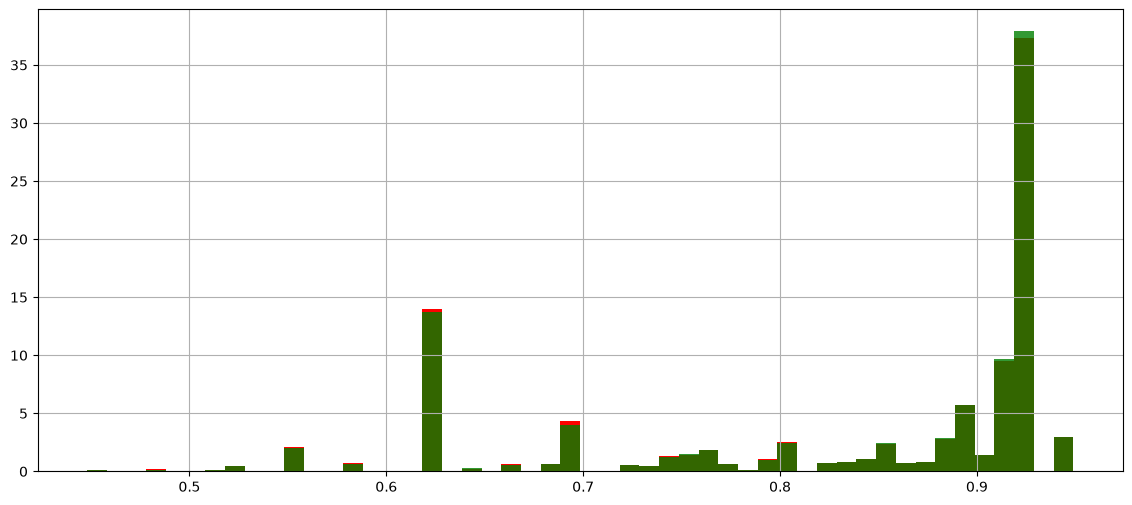

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data 
df['city_development_index'].hist(bins=50,ax=ax,density=True,figsize=(14,6),color='red')

#data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
reduced_df['city_development_index'].hist(bins=50,ax=ax,density=True,color='green',alpha=0.8)
plt.show()


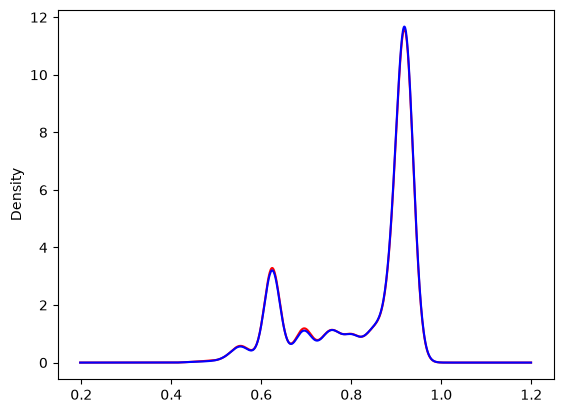

In [136]:
fig = plt.figure()
ax = fig.add_subplot(111)
# original data
df['city_development_index'].plot.density(color='red')
# data after CCA
reduced_df['city_development_index'].plot.density(color='blue')
plt.show()

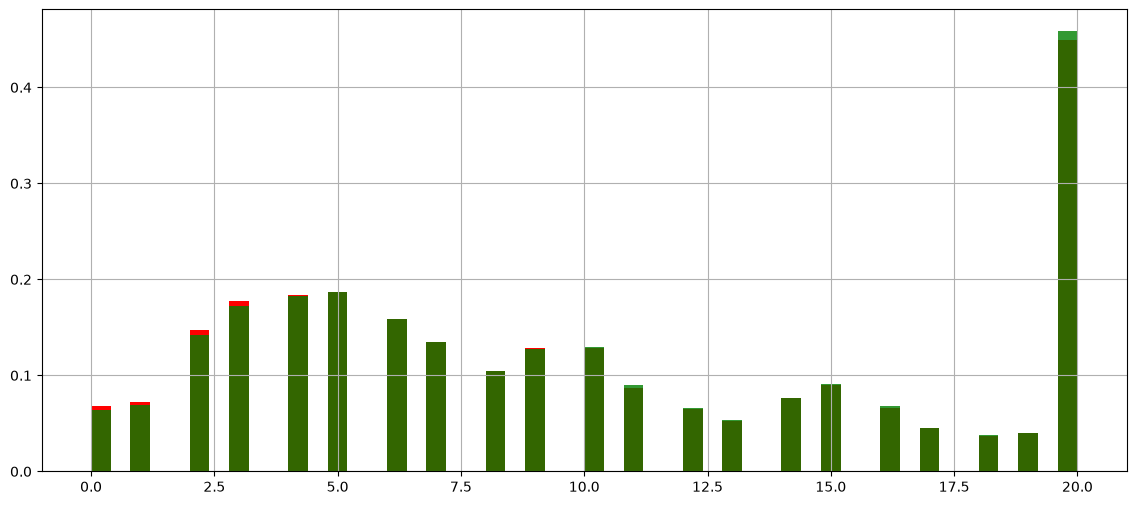

In [131]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data 
df['experience'].hist(bins=50,ax=ax,density=True,figsize=(14,6),color='red')

#data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
reduced_df['experience'].hist(bins=50,ax=ax,density=True,color='green',alpha=0.8)
plt.show()

<Axes: ylabel='Density'>

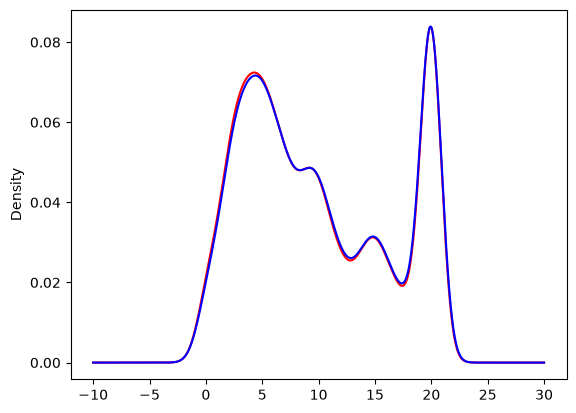

In [138]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data 
df['experience'].plot.density(color='red')

# AFTER CCA
reduced_df['experience'].plot.density(color='blue')


# how to check if dropping missing values of  a categorical is okay or not?
#### the ratio of the categories of a column with the total count of a column must be almost similar. <br> if the ratio drastically changes, then dropping the misssing values is not the best way to handle them.



In [139]:
df['enrolled_university'].value_counts() / len(df)

enrolled_university
no_enrollment       0.721213
Full time course    0.196106
Part time course    0.062533
Name: count, dtype: float64

In [141]:

temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            reduced_df['enrolled_university'].value_counts() / len(reduced_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

In [ ]:
temp # the ratio of categories are almost simialr,signifying it's okay to drop the missing values as a way to handle them.

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [144]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            reduced_df['education_level'].value_counts() / len(reduced_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
